# Target: 'Schema' 5 roots: Training two custom bilstms
# Feature extraction with EfficientNetV2B0

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from tensorflow.keras.layers import Input,LSTM,Bidirectional,Dense,BatchNormalization,Activation,MaxPooling2D,Dropout,Reshape,Conv2D,Flatten,GlobalAveragePooling2D,TimeDistributed

from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score , Precision, Accuracy, BinaryAccuracy, Recall ,AUC
import cv2
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input ,EfficientNetV2B0

2025-12-21 23:53:15.482537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766361195.677090      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766361195.733441      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#### Fixing Seed To ensure reproducibility

In [2]:
# # Set seed for reproducibility
# import random
# SEED = 42
# tf.random.set_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# os.environ['PYTHONHASHSEED'] = str(SEED)
# os.environ['TF_DETERMINISTIC_OPS'] = '1'

# Confuguration


In [3]:
TARGET_TYPE='Person'
EPOCHS=30
LR=1e-3
LOSS_FUNCTION='binary_crossentropy'
GRAY_SCALING=False

In [4]:
#metrics
f1_score=F1Score()
precision = Precision()
recall =Recall()
binary_accuracy=BinaryAccuracy()
# accuracy = Accuracy()
metrics=[f1_score,precision,recall,'accuracy',binary_accuracy]

class_position_in_path=5

I0000 00:00:1766361209.893746      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
print(tf.__version__)

2.18.0


# Data Preparation

In [6]:
def get_paths(parent_folder):
    import os
    files={}
    for i in os.walk(parent_folder):
        if i[-1]:
            files[i[0]]=[]
            image_name= i[-1][0]
#             files[i[0]].append(image_name)
            for image_name in i[-1]:
                files[i[0]].append(image_name)
    paths=[]
    for parent_path  in files.keys() :
        for image_name in files[parent_path]:
            paths.append(os.path.join(parent_path,image_name))
    return paths

def remove_not_image_files(paths):
    for p in paths:
        if not p.endswith('.png') and  not p.endswith('.jpg') and not p.endswith('.jpeg') and not p.endswith('.bmp'):
            print("path will be removed:"+p)
            paths.remove(p)
        else:
            try:
                plt.imread(p)
            except:
                paths.remove(p)
                print("cannot read path, will be removed:"+p)

    return paths

In [7]:
def preprocess_paths(parent_path):
    paths=get_paths(parent_path)
    n_paths_before=len(paths)
    i=0
    while(i<3):
        paths=remove_not_image_files(paths)
        i=i+1
    n_paths_after=len(paths)
    print(f"{n_paths_before - n_paths_after} paths have been removed from {n_paths_before}")
    return paths

In [8]:
parent_folder ='/kaggle/input/5-arabic-roots'
paths=preprocess_paths(parent_folder)

path will be removed:/kaggle/input/5-arabic-roots/corpus1/Corpus_Apprentissage_CNN_5_racines.xml
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/2_hom/Image_14_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_16_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/11_ghaeb/3_honna/Image_24_Arabic Transparent_1.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2_hom/Image_24_Arabic Transparent_4.png
cannot read path, will be removed:/kaggle/input/5-arabic-roots/corpus1/0/0/6_pr�sent/11_ghaeb/2

In [9]:
def get_ref_from_path(path,folder_position):
    if  path.startswith('/'):
        folder_position= folder_position+1
    return path.split('/')[folder_position]

In [10]:
def get_refs_from_paths(paths,folder_position):
    labels=[]
    for path in paths:
        labels.append(get_ref_from_path(path,folder_position))
    return labels

In [11]:
paths[0]

'/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�sent/10_moukhatab/2_antouma/Image_24_Arabic Transparent_15472.png'

## Choosing the target

In [12]:
refs=get_refs_from_paths(paths,class_position_in_path)

## Prepare dataframe:

In [13]:
d = {'path': paths, 'ref':refs}
df =pd.DataFrame.from_dict(d)

In [14]:
df

,path,ref
0,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
1,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
2,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
3,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
4,/kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...,2
...,...,...
1011,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1012,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1013,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3
1014,/kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...,3


## Select necessary words. 

In [15]:
def ref_to_label(refs:list):
    classes=sorted(list(set(refs)))
    labels = []
    labels_refs_map={}
    for ref in refs:
        labels_refs_map[classes.index(ref)]=ref
        labels.append(str(classes.index(ref)))
    return labels ,labels_refs_map
def prepare_dataframe(paths,refs):
    """
    Role:
        - Prepare dataframe  that conatains the paths of the images and its corresponding labels.
    Inputs:
        - paths : list()
        - labels: list()
    Outputs:
        df : pd.Dataframe()
    """
    import pandas as pd
    labels,REFS_LABELS_MAP = ref_to_label(refs)
    d = {'path': paths, 'ref':refs,'label':labels}
    df =pd.DataFrame.from_dict(d)
    return df,REFS_LABELS_MAP
# test:
df,REFS_LABELS_MAP =prepare_dataframe(df.path.values,df.ref.values)
df,REFS_LABELS_MAP

(                                                   path ref label
 0     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 1     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 2     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 3     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 4     /kaggle/input/5-arabic-roots/corpus1/0/2/6_pr�...   2     7
 ...                                                 ...  ..   ...
 1011  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1012  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1013  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1014  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 1015  /kaggle/input/5-arabic-roots/corpus1/76/3/5_pa...   3     8
 
 [1016 rows x 3 columns],
 {7: '2',
  0: '0',
  3: '15',
  5: '17',
  4: '16',
  8: '3',
  2: '14',
  6: '19',
  9: '5',
  1: '1'})

## Exploaratory data analysis

### Class Distribution 

In [16]:
#plot function
def show_plot(path):
    import matplotlib.pyplot as plt
    img = plt.imread(path)
    plt.imshow(img)

In [17]:
#plot function
def plot_distribution(classe_names,distribution,subset_name):
    plt.style.use('seaborn-dark-palette')
    classes=classe_names
    values =distribution
    plt.figure(figsize = (20, 5))
    plt.bar(classes, values,width = 0.7)

    plt.xlabel("Person id")
    plt.ylabel("Nb. words")
    plt.title(f"Repartition of {sum(values)} words in the {subset_name} data")
    def addlabels(x,y):
        for i in range(len(x)):
            plt.text(i, y[i], y[i], ha = 'center',color='black',style='italic',size="x-large")
    addlabels(classes,values)

In [18]:

series = df['ref'].value_counts()
values= series.values
keys = series.index

In [19]:
keys, len(keys)

(Index(['2', '0', '3', '15', '14', '1', '5', '17', '19', '16'], dtype='object', name='ref'),
 10)

/tmp/ipykernel_19/3035305012.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


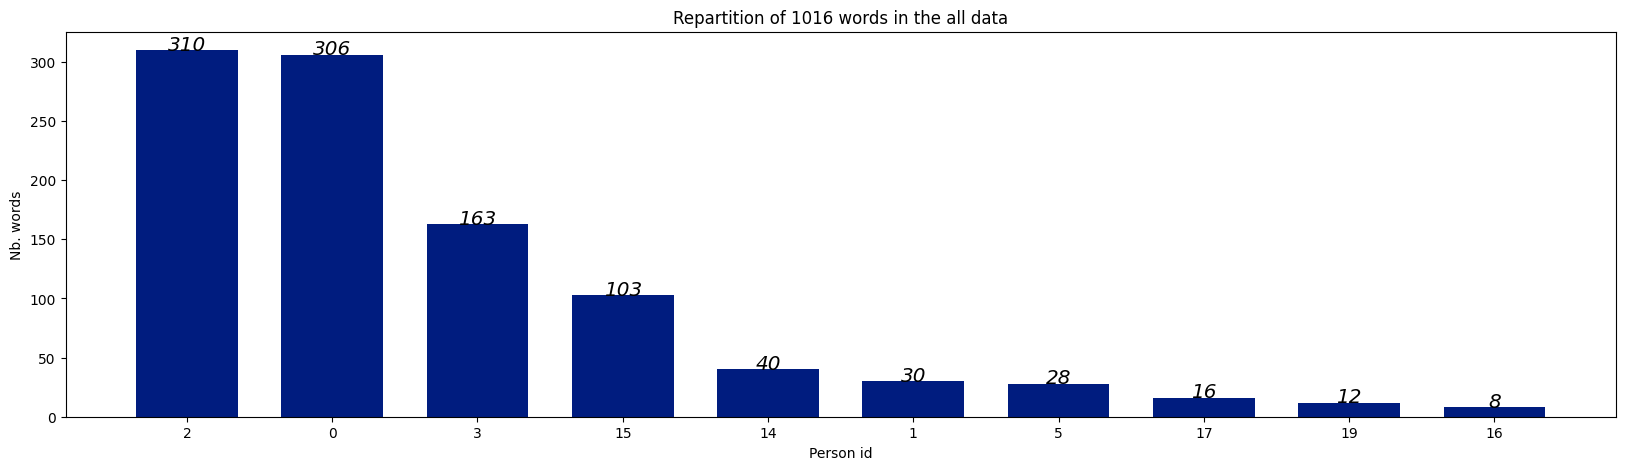

In [20]:
plot_distribution(keys,values,'all')

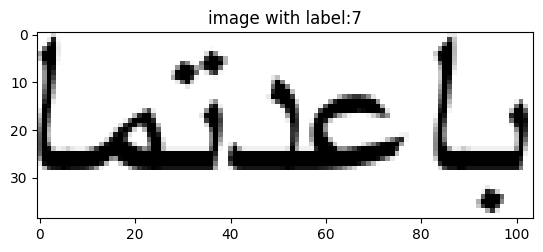

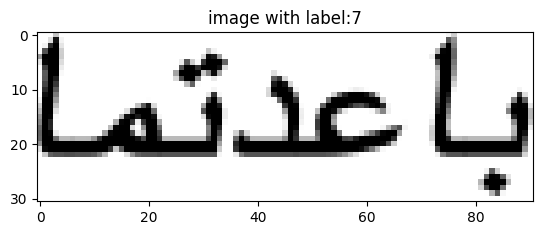

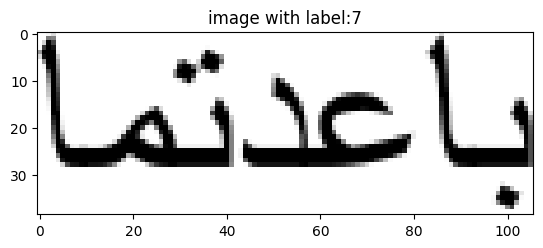

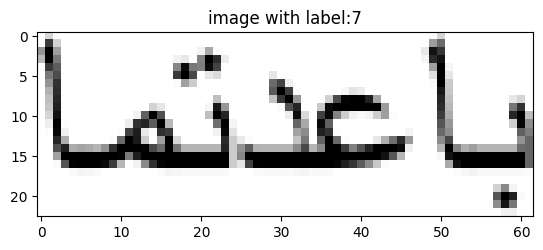

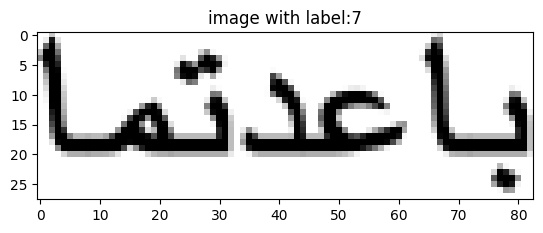

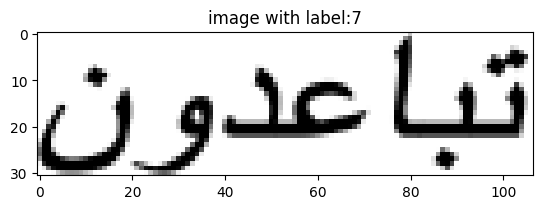

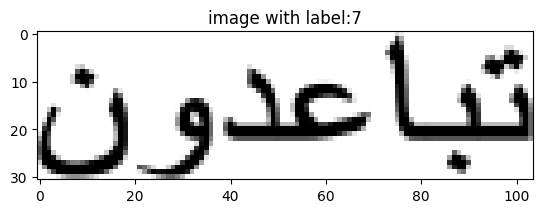

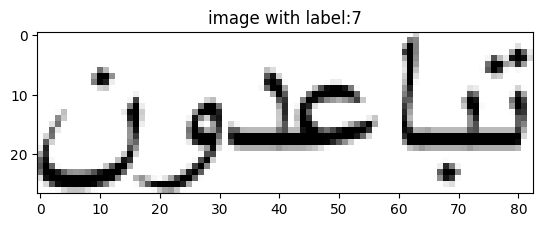

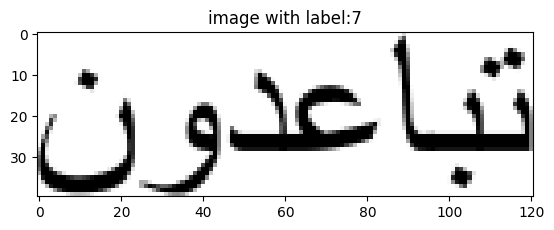

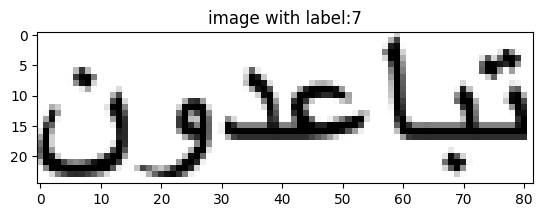

In [21]:
for i,path in enumerate(df['path'][:10]):
    im = cv2.imread(path)
    plt.figure()
    plt.title("image with label:"+df['label'][i])
    plt.imshow(im)

## split data :train ,test ,val

In [22]:
from sklearn.model_selection import train_test_split
train_df,test_df = train_test_split(df,test_size=0.2,shuffle=True,stratify=df['label'])
# val_df,test_df = train_test_split(test_df,test_size=0.5,shuffle=True,stratify=test_df['label'])

In [23]:
train_series = train_df['ref'].value_counts()
train_values = train_series.values
train_keys = train_series.index

/tmp/ipykernel_19/3035305012.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


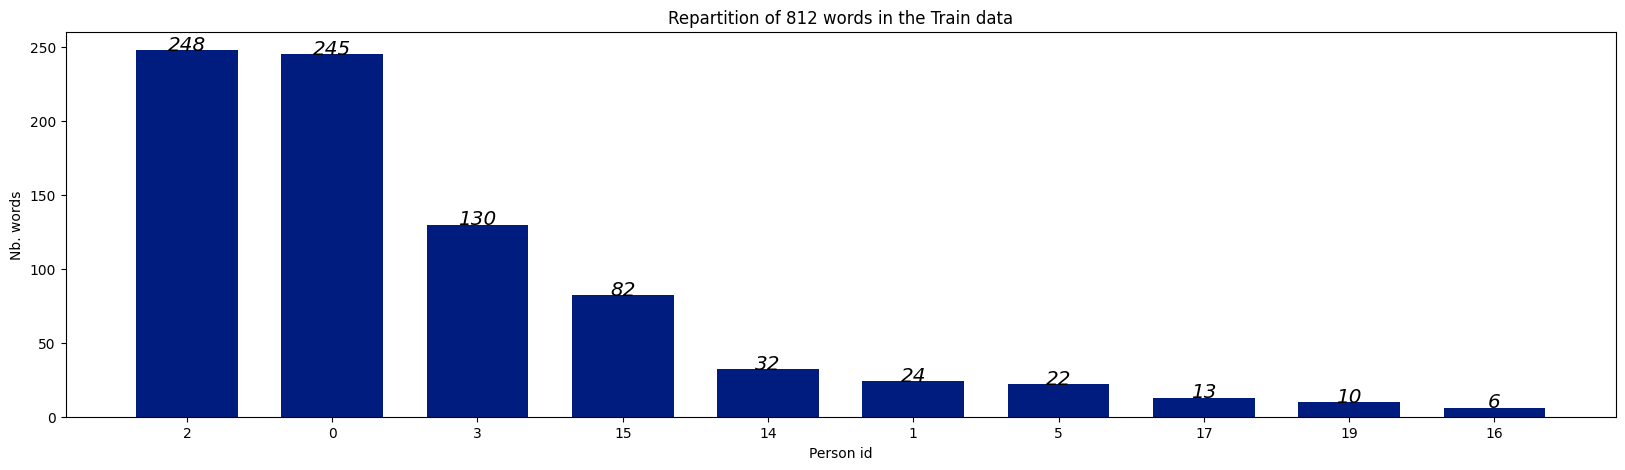

In [24]:
plot_distribution(train_keys,train_values,'Train')

## Test data

In [25]:
test_series = test_df['ref'].value_counts()
test_values = test_series.values
test_keys = test_series.index

/tmp/ipykernel_19/3035305012.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


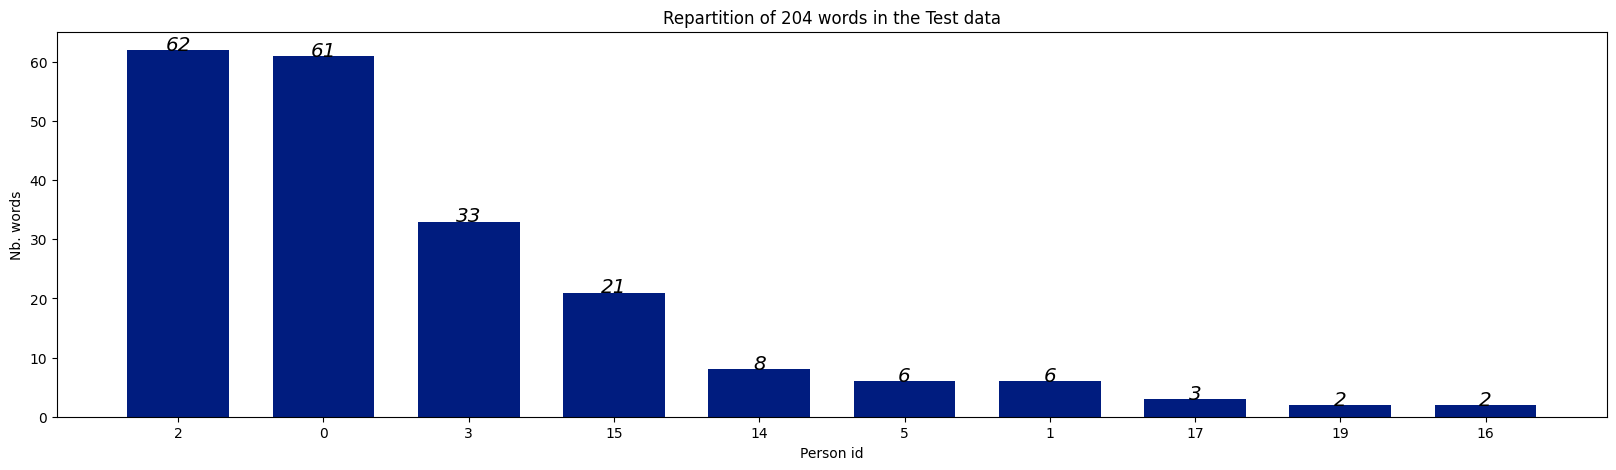

In [26]:
plot_distribution(test_keys,test_values,'Test')

## Load images and prepare lables

In [27]:
def reshape_image(img):
    import cv2
    import numpy as np
    (h, w,d) = img.shape
    
    final_img = np.ones([128, 256,3])*255 # blank white image
    
    # crop
    if w > 256:
        img = img[:, :256]
        
    if h > 128:
        img = img[:128, :]
        
    final_img[:h,:w,:d] = img
    # return cv2.rotate(final_img, cv2.ROTATE_90_CLOCKWISE)
    return final_img

def prepare_images(paths):
    import cv2
    import numpy as np
    images=[]
    bad_images_indexs=[]
    for i,path in enumerate(paths):
        try:
            if(GRAY_SCALING):
                im = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
            else:
                im = cv2.imread(path)
                
            im = reshape_image(im)
            im = im/255.
            images.append(im)
        except:
            bad_images_indexs.append(i)
            print(f"Error loading image {path}")
    print(f"found {len(images)} images with {im.shape} shapes")
    return images , bad_images_indexs

In [28]:
def prepare_xy(paths,labels):
    x,bad_images_indexs = prepare_images(paths)
    cleaned_labels=[]
    for i,label in enumerate(labels):
        if i not in bad_images_indexs:
            cleaned_labels.append(label)
    y = tf.keras.utils.to_categorical(cleaned_labels)
    return x ,y

In [29]:
len(paths)

1016

### Image generator

In [30]:
generator = ImageDataGenerator(preprocessing_function=reshape_image)

In [31]:
ALL_CLASSES=df['label'].value_counts().index
ALL_CLASSES

Index(['7', '0', '8', '3', '2', '1', '9', '5', '6', '4'], dtype='object', name='label')

## Train data

In [32]:
train_df.shape,len(train_df['label'])

((812, 3), 812)

In [33]:
train_df['label'].value_counts().sum()

812

In [34]:
train_df

,path,ref,label
727,/kaggle/input/5-arabic-roots/corpus1/74/15/1/3...,15,3
52,/kaggle/input/5-arabic-roots/corpus1/0/2/5_pas...,2,7
798,/kaggle/input/5-arabic-roots/corpus1/76/2/6_pr...,2,7
628,/kaggle/input/5-arabic-roots/corpus1/74/2/5_pa...,2,7
295,/kaggle/input/5-arabic-roots/corpus1/34/16/nom...,16,4
...,...,...,...
350,/kaggle/input/5-arabic-roots/corpus1/34/3/5_pa...,3,8
527,/kaggle/input/5-arabic-roots/corpus1/16/1/5_pa...,1,1
839,/kaggle/input/5-arabic-roots/corpus1/76/2/5_pa...,2,7
373,/kaggle/input/5-arabic-roots/corpus1/34/14/nom...,14,2


In [35]:
train_gen=generator.flow_from_dataframe(
    dataframe=train_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 812 validated image filenames belonging to 10 classes.


In [36]:
images, labels=next(train_gen)

In [37]:
labels

array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

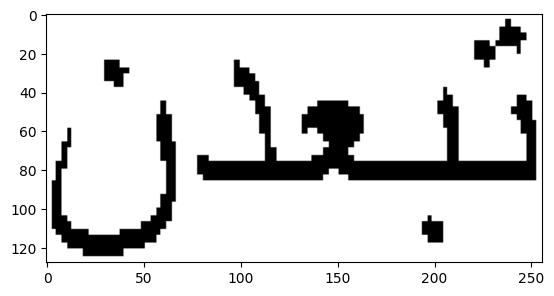

In [38]:
plt.imshow(images[15])

# Test DATA

In [39]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=True
)

Found 204 validated image filenames belonging to 10 classes.


# Training

In [40]:
backbone=EfficientNetV2B0(weights='imagenet',include_top=False,input_shape=(128, 256, 3))

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
# CLASS_NAMES=np.unique(train_gen.labels)
CLASS_NAMES = np.unique(train_gen.labels) 
NB_CLASSES=len(CLASS_NAMES) # also len(train_gen.class_indices)
CLASS_NAMES,NB_CLASSES

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), 10)

In [42]:
input_data = backbone.input 
inner = backbone.output
##  Bidirectional lstm from scratch : 
inner = Reshape(target_shape=(32,1280), name='reshape')(inner)
inner = Bidirectional(LSTM(256, return_sequences=True), name = 'bilstm1')(inner)
inner = Bidirectional(LSTM(256, return_sequences=False), name = 'bilstm2')(inner)

inner = Dense(1000, activation='relu', kernel_initializer='he_normal', name='dense2')(inner)
## OUTPUT
inner = Dense(NB_CLASSES, kernel_initializer='he_normal',name='dense3')(inner)
y_pred = Activation('sigmoid', name='sigmoid')(inner)
model = Model(inputs=input_data, outputs=y_pred)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 128, 256, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 128, 256, 3)    │              0 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 64, 128, 32)    │            864 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 64, 128, 32)    │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 64, 128, 32)    │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 64, 128, 16)    │          4,608 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 64, 128, 16)    │             64 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 64, 128, 16)    │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_conv       │ (None, 32, 64, 64)     │          9,216 │ block1a_project_activ… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_bn         │ (None, 32, 64, 64)     │            256 │ block2a_expand_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_expand_activation │ (None, 32, 64, 64)     │              0 │ block2a_expand_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_conv      │ (None, 32, 64, 32)     │          2,048 │ block2a_expand_activa… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2a_project_bn        │ (None, 32, 64, 32)     │            128 │ block2a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 11,165,010 (42.59 MB)

 Trainable params: 11,104,402 (42.36 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [43]:
model.compile(optimizer=Adam(LR),loss=LOSS_FUNCTION,metrics=metrics)

In [44]:
BATCH_SIZE=8
STEPS=int(train_gen.n / BATCH_SIZE) + 1
history=model.fit(train_gen,
                   validation_data=test_gen,
                   steps_per_epoch=STEPS,
                   epochs=EPOCHS,
                   verbose=2)

Epoch 1/30


E0000 00:00:1766361284.707503      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1766361290.126415      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your

102/102 - 82s - 802ms/step - accuracy: 0.5998 - binary_accuracy: 0.9169 - f1_score: 0.3021 - loss: 0.1995 - precision: 0.5983 - recall: 0.5135 - val_accuracy: 0.7157 - val_binary_accuracy: 0.9422 - val_f1_score: 0.5274 - val_loss: 0.1333 - val_precision: 0.7416 - val_recall: 0.6471
Epoch 2/30
102/102 - 6s - 63ms/step - accuracy: 0.8855 - binary_accuracy: 0.9773 - f1_score: 0.7526 - loss: 0.0651 - precision: 0.9110 - recall: 0.8571 - val_accuracy: 0.9510 - val_binary_accuracy: 0.9912 - val_f1_score: 0.8087 - val_loss: 0.0270 - val_precision: 0.9604 - val_recall: 0.9510
Epoch 3/30
102/102 - 6s - 61ms/step - accuracy: 0.9200 - binary_accuracy: 0.9830 - f1_score: 0.8412 - loss: 0.0470 - precision: 0.9223 - recall: 0.9064 - val_accuracy: 0.9461 - val_binary_accuracy: 0.9902 - val_f1_score: 0.9055 - val_loss: 0.0330 - val_precision: 0.9510 - val_recall: 0.9510
Epoch 4/30
102/102 - 6s - 61ms/step - accuracy: 0.9680 - binary_accuracy: 0.9931 - f1_score: 0.9243 - loss: 0.0240 - precision: 0.969

In [45]:
model.save("Schema_30_ep_5roots_bilstm.keras")

In [46]:
model=tf.keras.models.load_model("/kaggle/working/Schema_30_ep_5roots_bilstm.keras")

In [47]:
np.save("Schema_30_ep_5roots_bilstm_training_history.npy", history.history, allow_pickle=True)

In [48]:
history.history.keys()

dict_keys(['accuracy', 'binary_accuracy', 'f1_score', 'loss', 'precision', 'recall', 'val_accuracy', 'val_binary_accuracy', 'val_f1_score', 'val_loss', 'val_precision', 'val_recall'])

In [49]:
keys=['binary_accuracy','f1_score','loss','precision', 'accuracy','recall']

/tmp/ipykernel_19/4161447496.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-dark-palette')


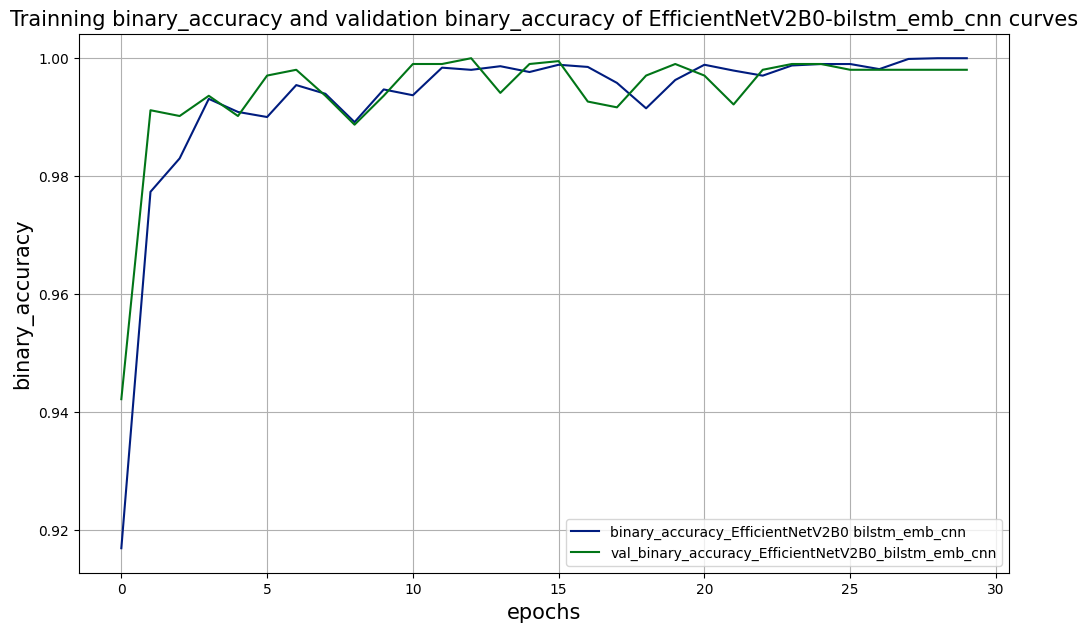

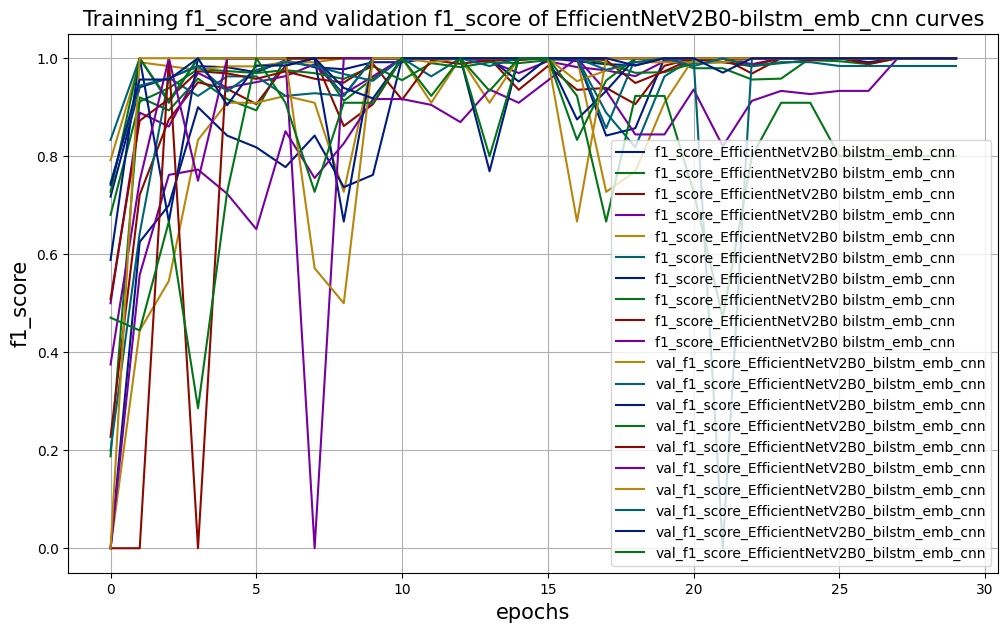

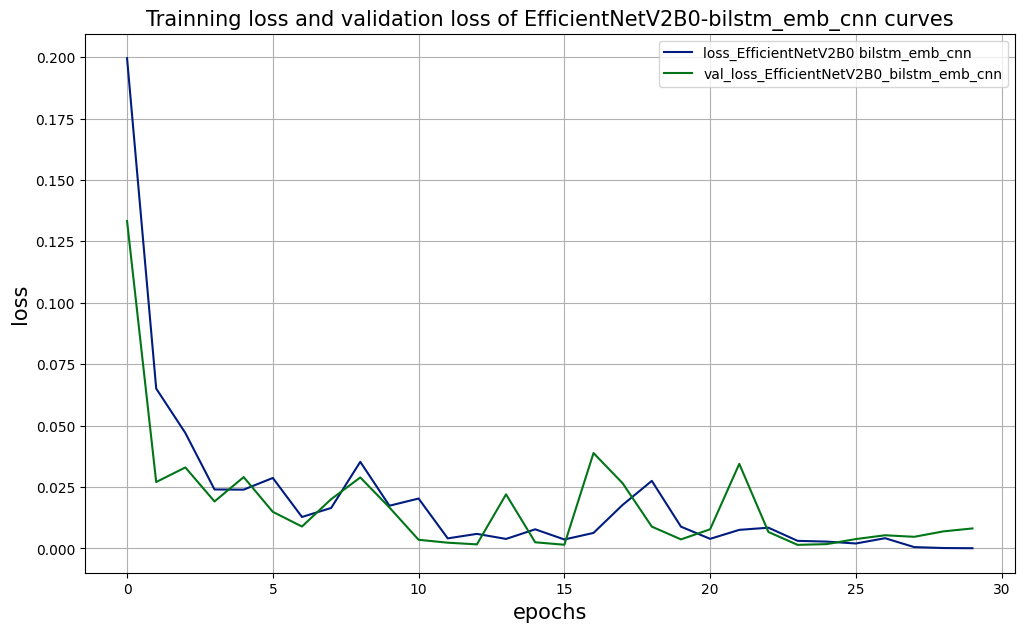

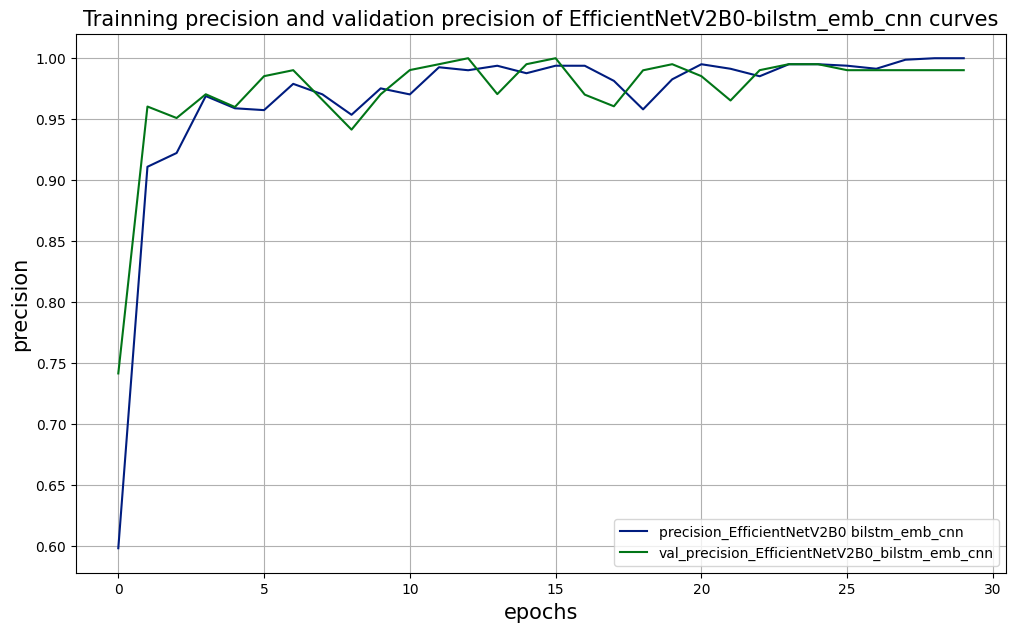

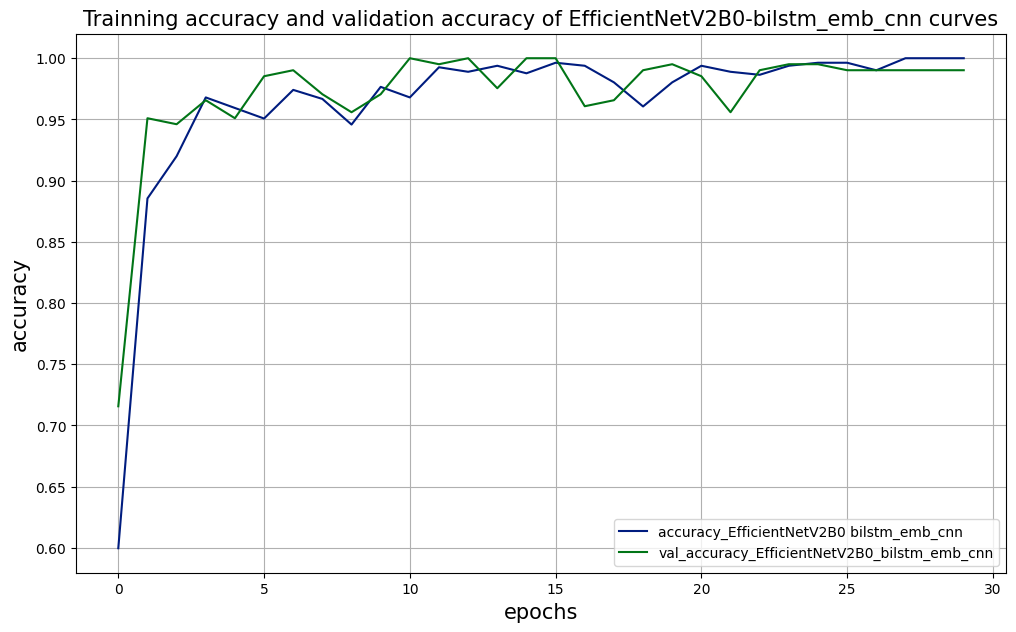

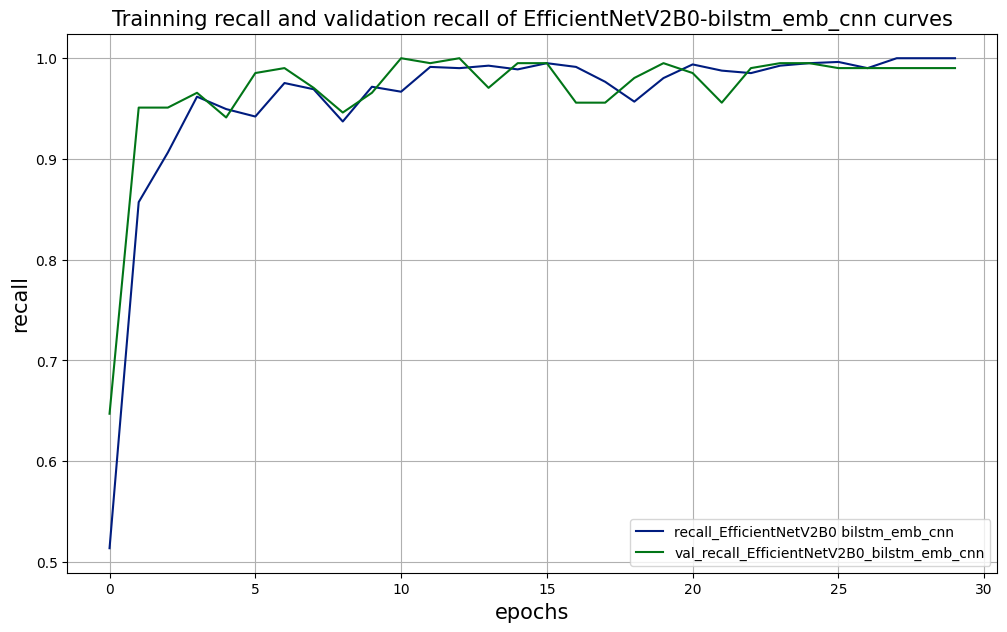

In [50]:
plt.style.use('seaborn-dark-palette')
for key in keys:
    plt.figure(figsize=(12,7))
    plt.plot(history.history[f'{key}'],label=f'{key}_EfficientNetV2B0 bilstm_emb_cnn',)
    plt.legend()
    plt.plot(history.history[f'val_{key}'],label=f'val_{key}_EfficientNetV2B0_bilstm_emb_cnn')
    plt.legend()
    plt.title(f'Trainning {key} and validation {key} of EfficientNetV2B0-bilstm_emb_cnn curves',fontsize=15)
    plt.xlabel('epochs',fontsize=15)
    plt.grid()
    plt.ylabel(key,fontsize=15)

In [51]:
res0_train=model.evaluate(train_gen)
res0_train

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 1.0000 - binary_accuracy: 1.0000 - f1_score: 0.9712 - loss: 1.2872e-04 - precision: 1.0000 - recall: 1.0000


[8.214219269575551e-05,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32)>,
 1.0,
 1.0,
 1.0,
 1.0]

51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step


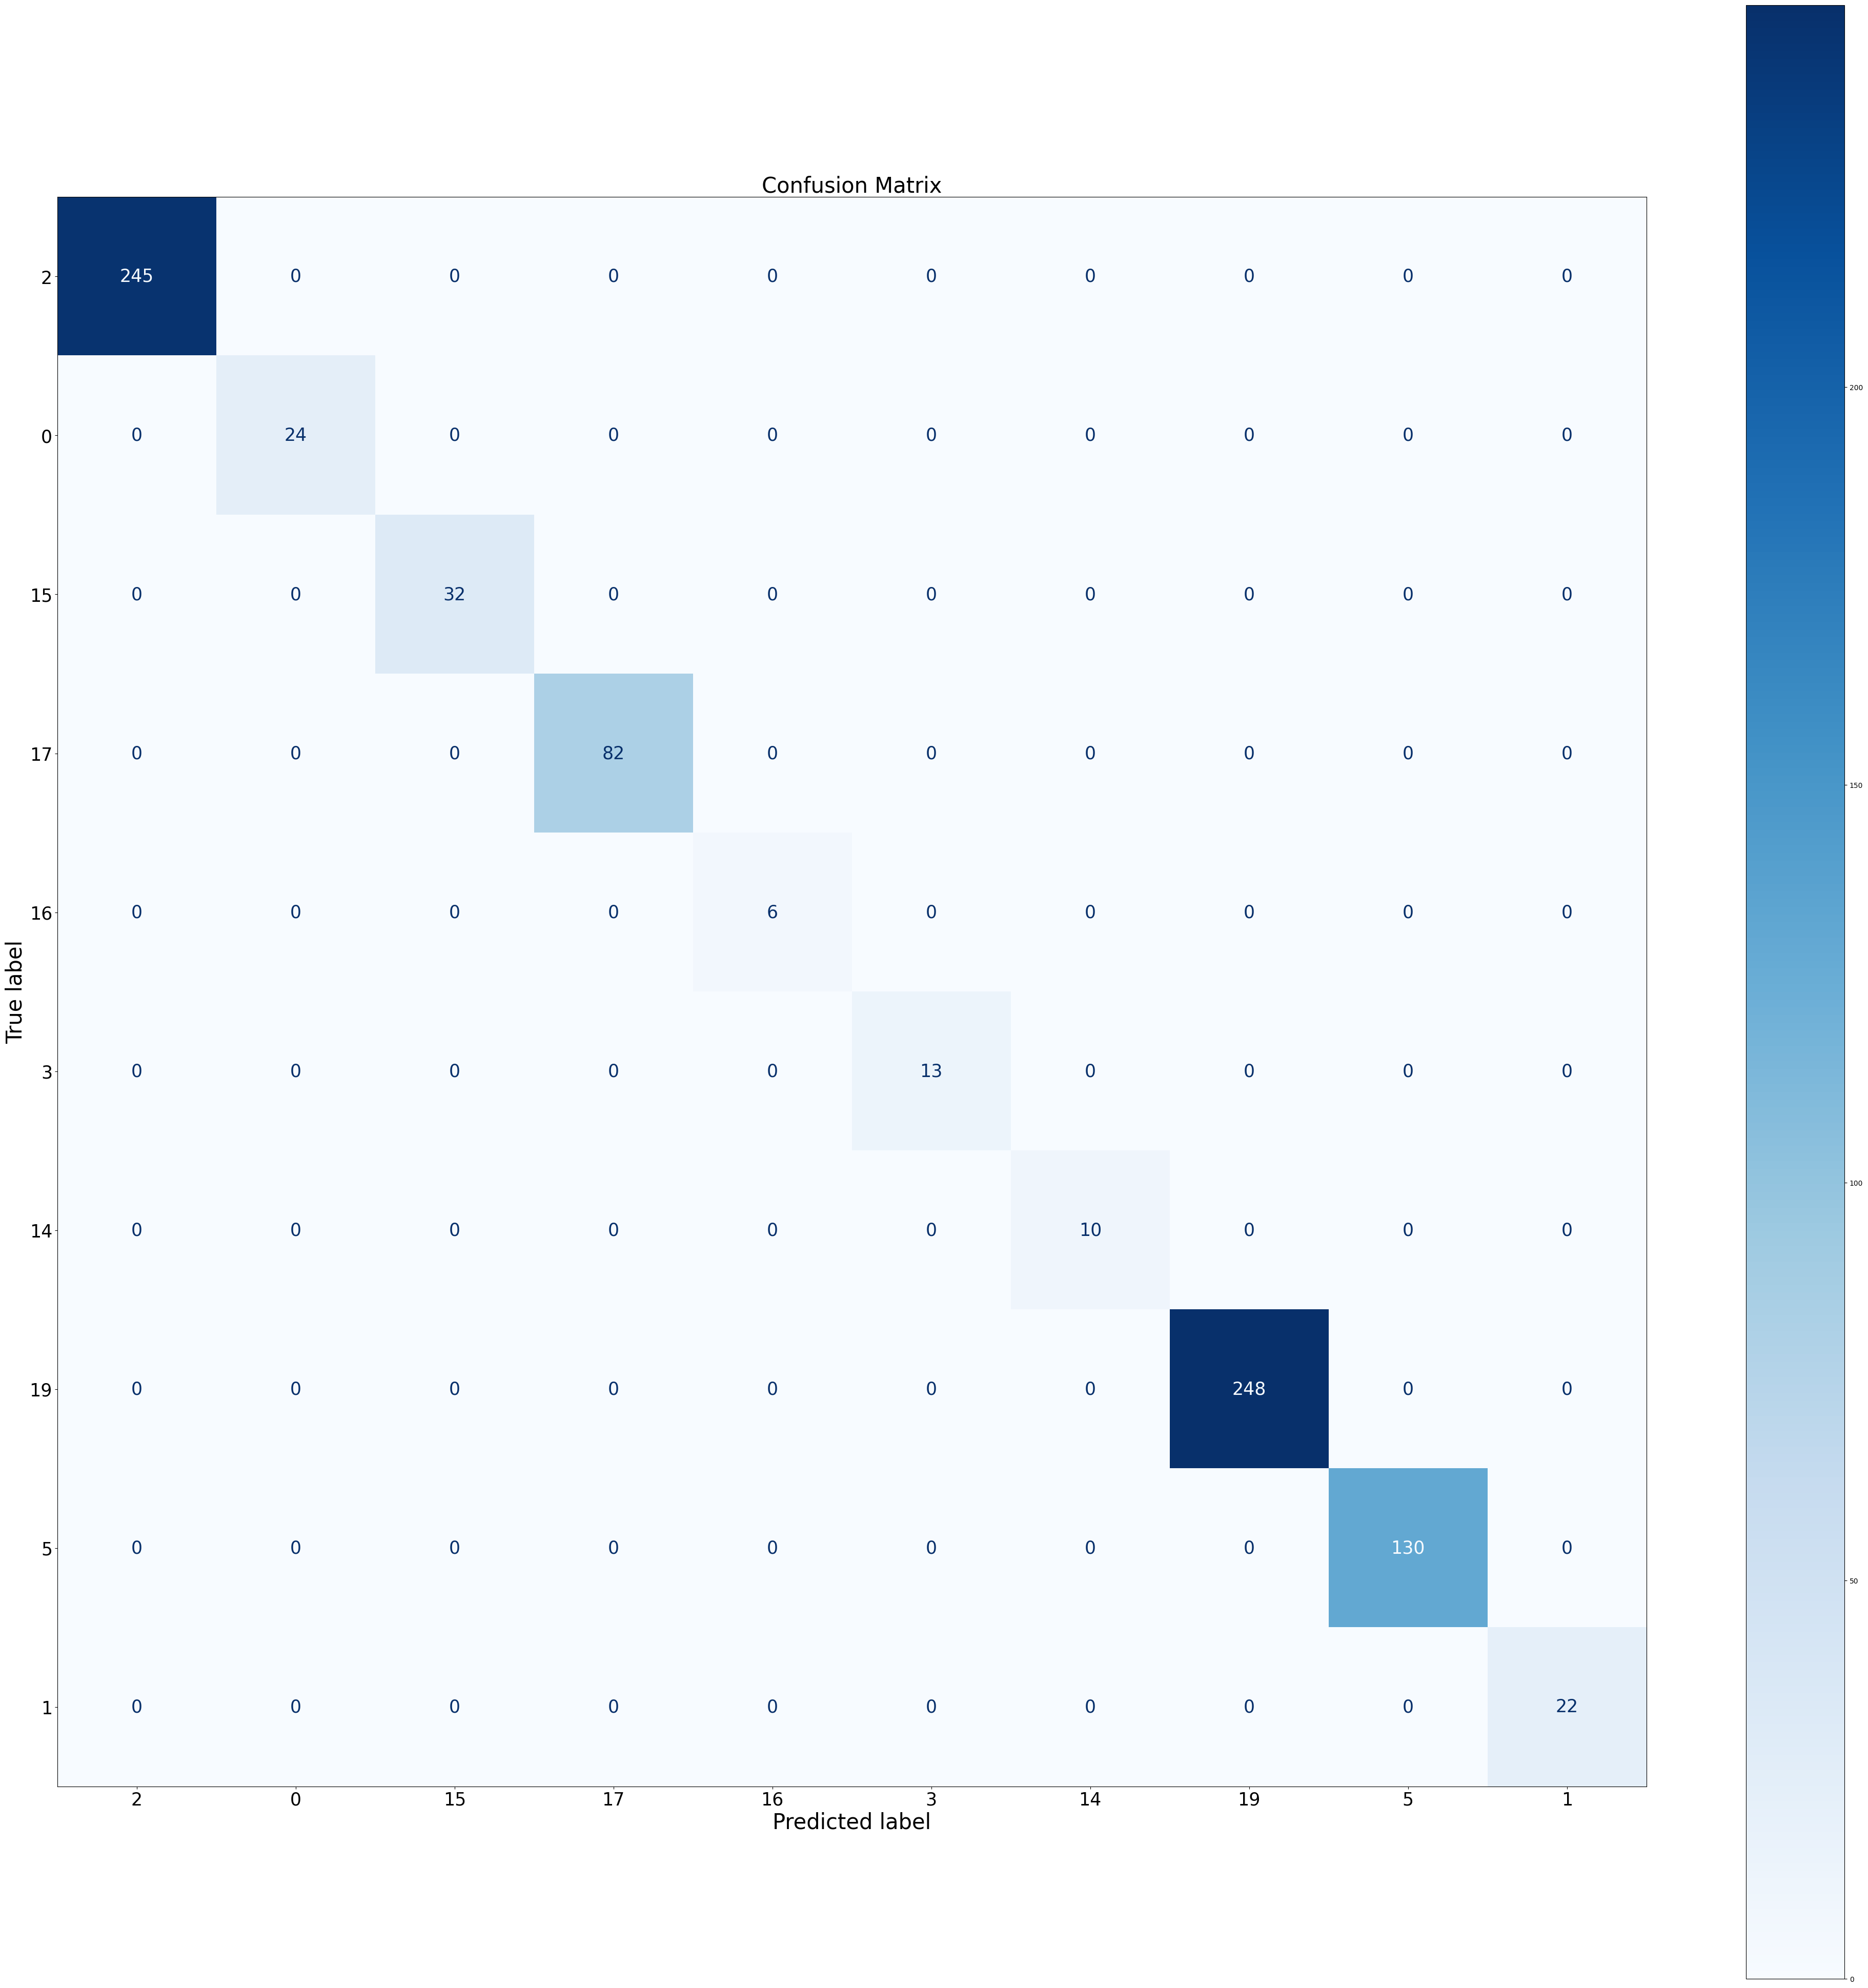

In [52]:
Y_res0_train= model.predict(train_gen)
Y_res0_train=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_train]
y_train_classes=[REFS_LABELS_MAP[y] for y in train_gen.labels]
cm=confusion_matrix(y_train_classes,Y_res0_train)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

In [53]:
from sklearn.metrics import classification_report
repport =classification_report(y_train_classes,Y_res0_train)
print(repport)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        32
          15       1.00      1.00      1.00        82
          16       1.00      1.00      1.00         6
          17       1.00      1.00      1.00        13
          19       1.00      1.00      1.00        10
           2       1.00      1.00      1.00       248
           3       1.00      1.00      1.00       130
           5       1.00      1.00      1.00        22

    accuracy                           1.00       812
   macro avg       1.00      1.00      1.00       812
weighted avg       1.00      1.00      1.00       812



##  shuffle=False in the test_gen:

In [54]:
test_gen=generator.flow_from_dataframe(
    dataframe=test_df,
    directory='/',
    x_col='path',
    y_col='label',
    class_mode='categorical',
    color_mode='rgb',
    batch_size=16,
    target_size=(128,256),
    shuffle=False
)

Found 204 validated image filenames belonging to 10 classes.


In [55]:
res0_test=model.evaluate(test_gen)
res0_test

 5/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9715 - binary_accuracy: 0.9943 - f1_score: 0.7550 - loss: 0.0210 - precision: 0.9715 - recall: 0.9715

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9811 - binary_accuracy: 0.9962 - f1_score: 0.8523 - loss: 0.0147 - precision: 0.9811 - recall: 0.9811


[0.00814523734152317,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.9841269 , 1.        , 0.79999995],
       dtype=float32)>,
 0.9901960492134094,
 0.9901960492134094,
 0.9901960492134094,
 0.9980392456054688]

In [56]:
len(CLASS_NAMES)

10

### Metrics

#### Confusion Matrix

In [57]:
test_gen.class_indices

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

In [58]:
REFS_LABELS_MAP

{7: '2',
 0: '0',
 3: '15',
 5: '17',
 4: '16',
 8: '3',
 2: '14',
 6: '19',
 9: '5',
 1: '1'}

In [59]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[np.argmax(y) for y in Y_res0_test]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [60]:
Y_res0_test[10:20],test_gen.labels[10:20]

([8, 0, 7, 7, 0, 7, 7, 3, 0, 3], [8, 0, 9, 7, 0, 7, 7, 3, 0, 3])

In [61]:
test_gen.filenames[:10]

['/kaggle/input/5-arabic-roots/corpus1/16/0/5_pass�/10_ghaeb/5_honna/Image_14_Arabic Transparent_9460.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/3/5_pass�/10_moukhatab/1_antom/Image_18_Arabic Transparent_2143.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/2/5_pass�/11_ghaeb/2_houma_m/Image_24_Arabic Transparent_1514.png',
 '/kaggle/input/5-arabic-roots/corpus1/74/15/2/3_masculin/7_marfou3/Image_24_Arabic Transparent_1499.png',
 '/kaggle/input/5-arabic-roots/corpus1/34/2/6_pr�sent/10_moukhatab/1_anti/Image_14_Arabic Transparent_2201.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/15/nom/2/3_masculin/8_mansoub/Image_18_Arabic Transparent_1042_5.png',
 '/kaggle/input/5-arabic-roots/corpus1/76/3/6_pr�sent/10_moukhatab/4_antonna/Image_24_Arabic Transparent_1098_1.png',
 '/kaggle/input/5-arabic-roots/corpus1/16/0/5_pass�/10_ghaeb/0_houa/Image_24_Arabic Transparent_9383_1.png',
 '/kaggle/input/5-arabic-roots/corpus1/16/14/nom/2/3_masculin/7_marfou3/Image_24_Arabic Transparent_9046.png',

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


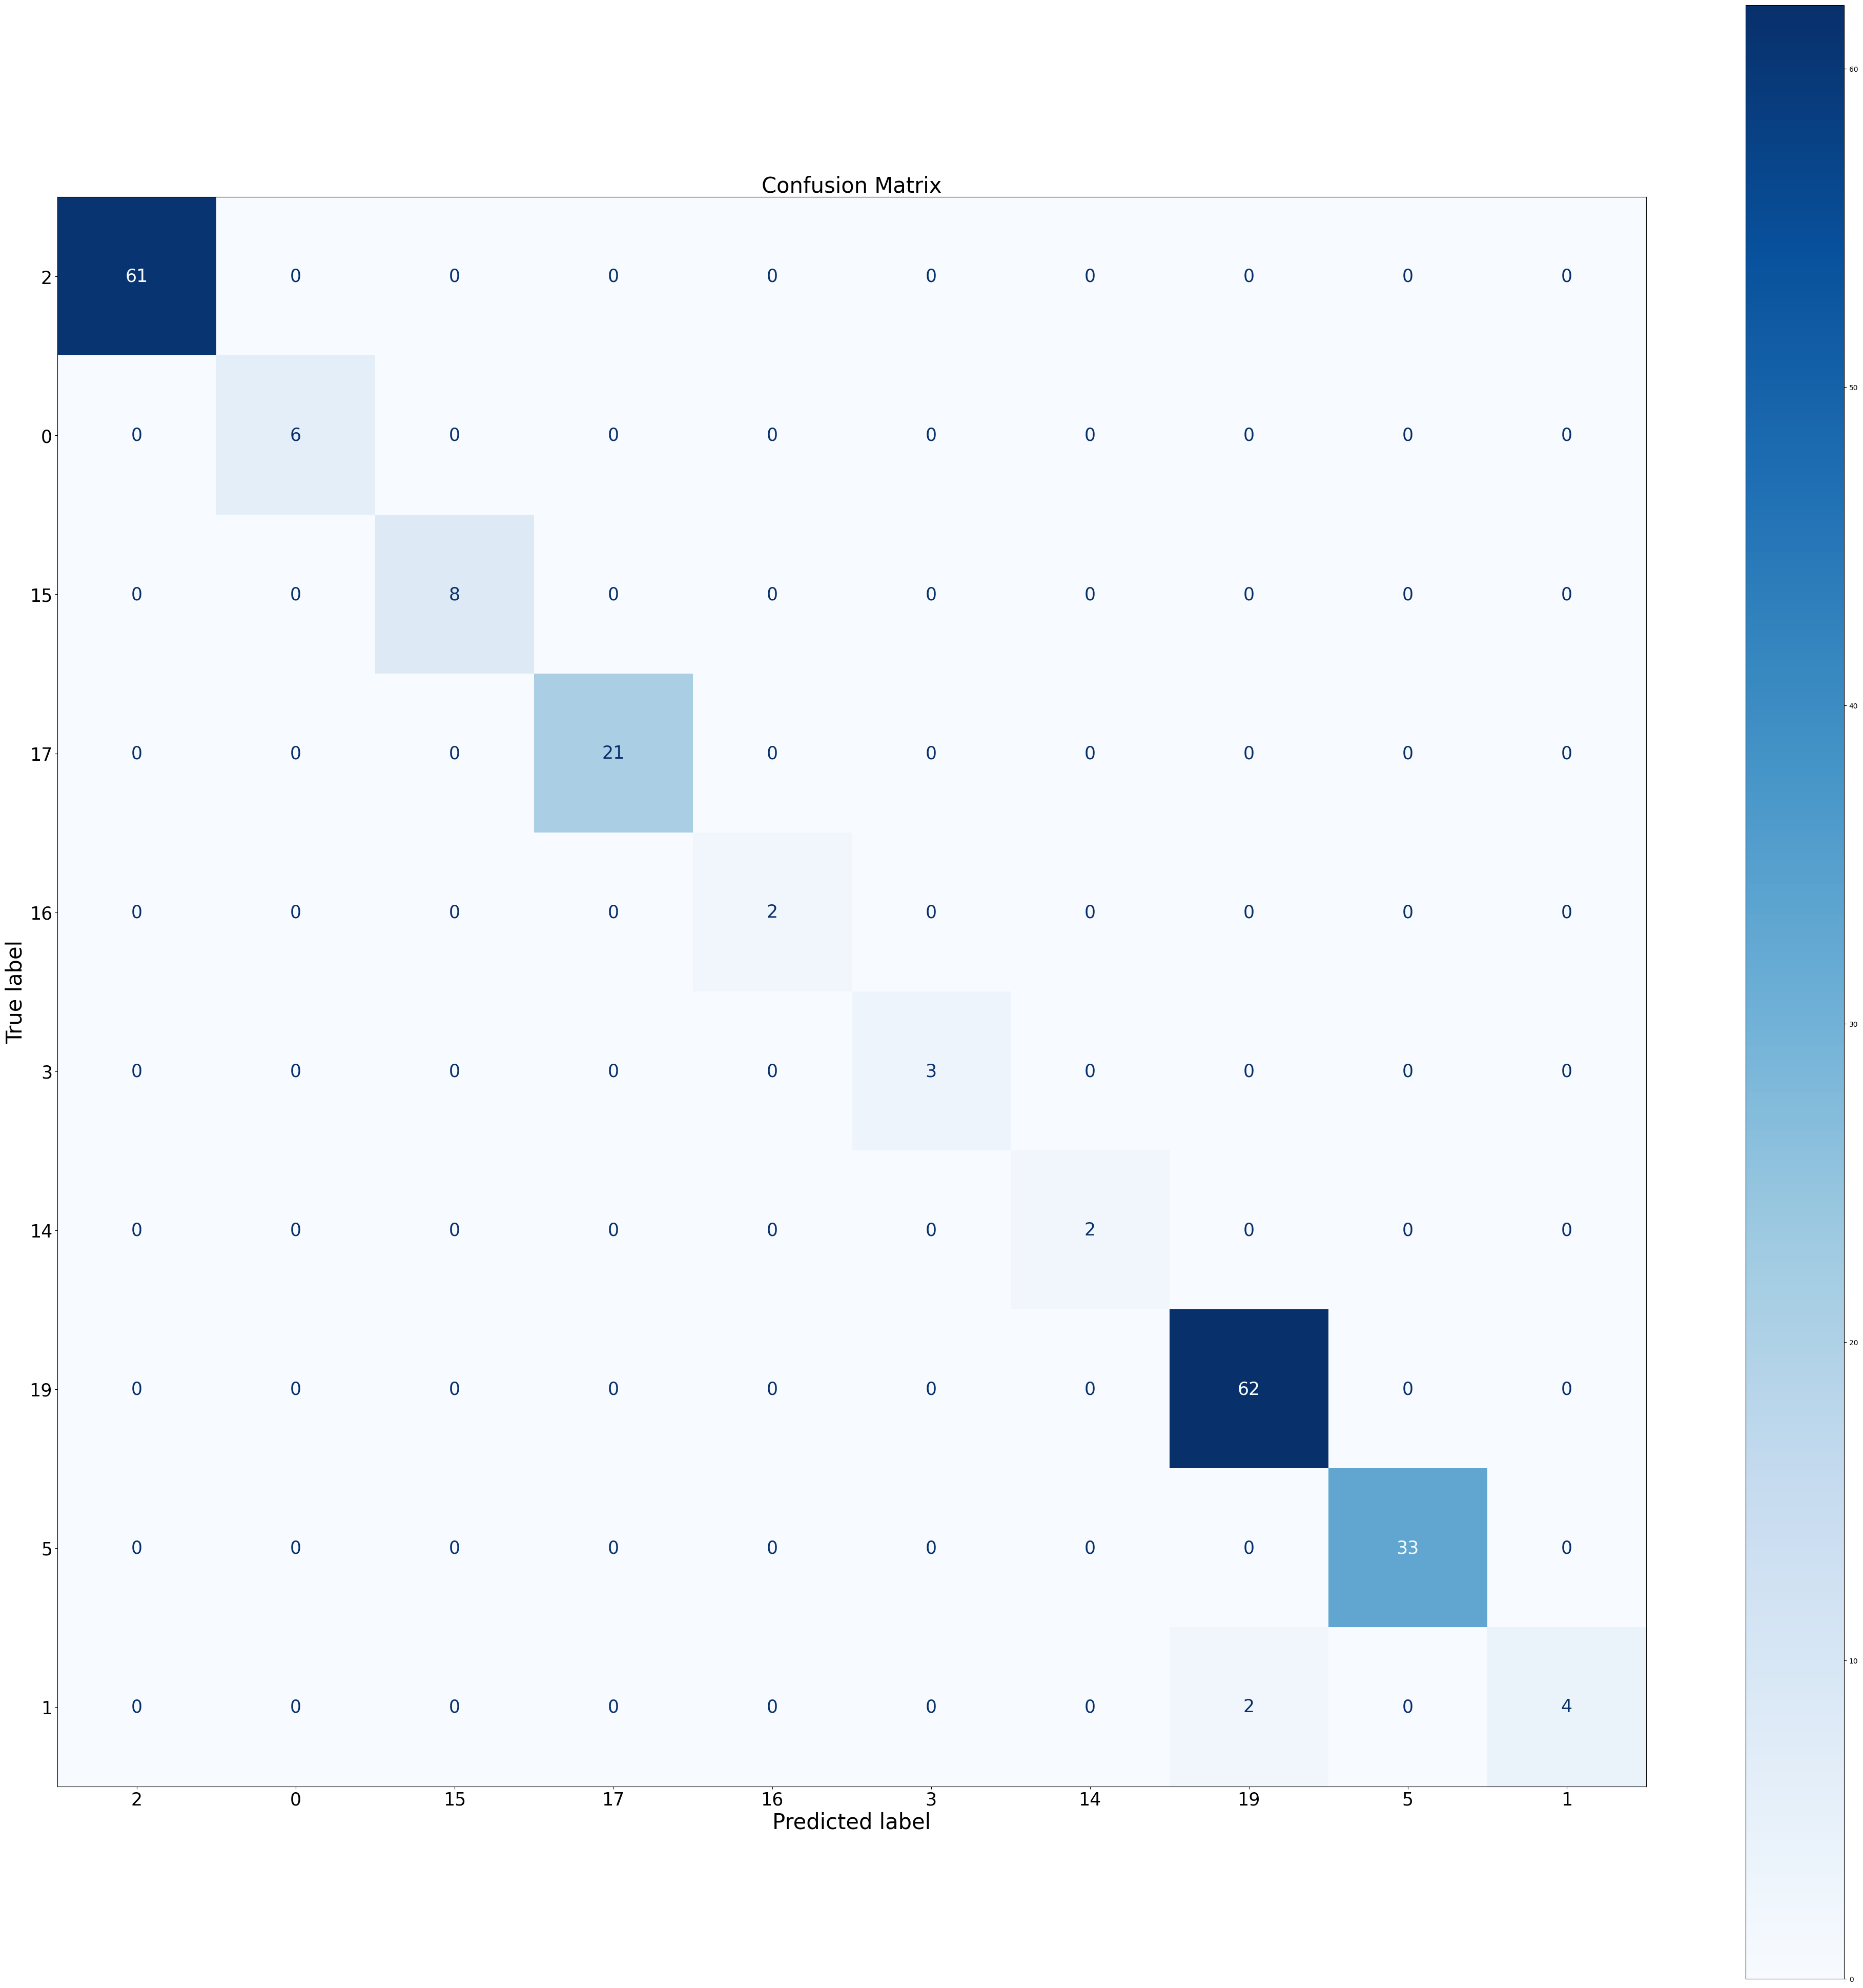

In [62]:
Y_res0_test= model.predict(test_gen)
Y_res0_test=[REFS_LABELS_MAP[np.argmax(y)] for y in Y_res0_test]
y_test_classes=[REFS_LABELS_MAP[y] for y in test_gen.labels]
cm=confusion_matrix(y_test_classes,Y_res0_test)
from sklearn.metrics import ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(cm,display_labels=REFS_LABELS_MAP.values())
fig, ax = plt.subplots(figsize=(50, 50))  # Adjusted size for better readability
plt.xticks(fontsize=25)  # Set font size for x-axis labels
plt.yticks(fontsize=25)  # Set font size for y-axis labels
plt.xlabel("Predicted Label", fontsize=30)
plt.ylabel("True Label", fontsize=30)
plt.title("Confusion Matrix", fontsize=30)
cmd.plot(cmap='Blues',ax=ax)
for i in range(len(cmd.text_)):
    for j in range(len(cmd.text_[i])):
        cmd.text_[i][j].set_fontsize(25)  # Set the font size for the numbers inside the cells

plt.show()

#### Classification report

In [63]:
from sklearn.metrics import classification_report
repport =classification_report(y_test_classes,Y_res0_test)
print(repport)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00         6
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00        21
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          19       1.00      1.00      1.00         2
           2       0.97      1.00      0.98        62
           3       1.00      1.00      1.00        33
           5       1.00      0.67      0.80         6

    accuracy                           0.99       204
   macro avg       1.00      0.97      0.98       204
weighted avg       0.99      0.99      0.99       204



#### Top-5 accuracy

In [64]:
from sklearn.metrics import top_k_accuracy_score
y_test_scores=model.predict(test_gen)
top_5_accuracy=top_k_accuracy_score(test_gen.labels,y_test_scores,k=5)
print("the Top 5 accuracy score: "+ str(top_5_accuracy))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
the Top 5 accuracy score: 1.0


### Wrong test predictions 

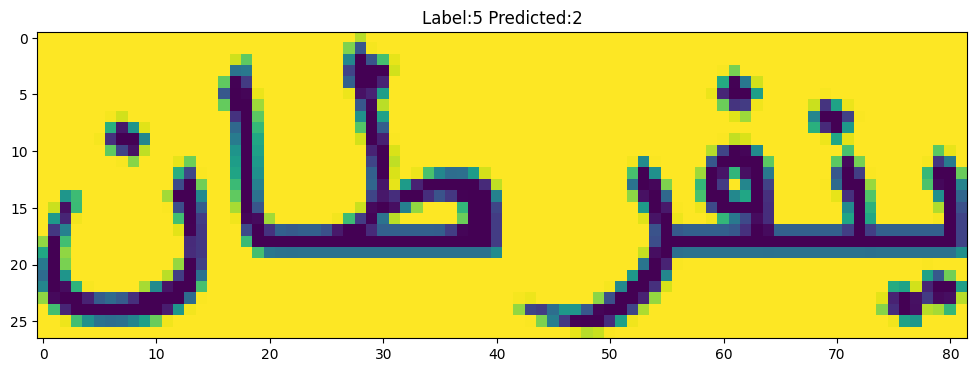

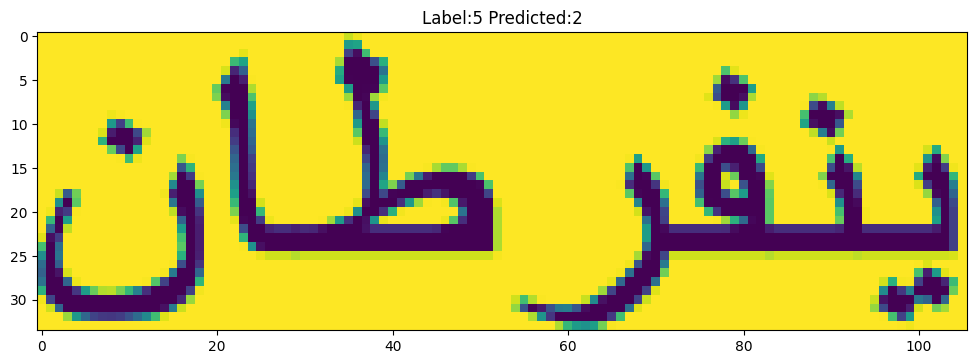

In [65]:
for index in range(len(Y_res0_test)):
    if Y_res0_test[index] !=y_test_classes[index]:
        img  =plt.imread(test_df['path'].values[index])
        plt.figure(figsize=(12,6))
        plt.title("Label:"+y_test_classes[index]+" Predicted:"+Y_res0_test[index])
        plt.imshow(img)